# Insights on controlled gates

In this notebook we go through some examples to clarify how controlled gates work in quantum computing

## First example: CNOT

A (wrong) way to interpret quantum computing is to think that the qubit is either in one state ($\vert0\rangle$) or the other ($\vert1\rangle$), and when we measure it we uncover that state. 

Controlled gates are perfect to refute this conception. Let's see the CNOT gate in action!

$CNOT=\begin{pmatrix}1&0&0&0 \\ 0&1&0&0 \\ 0&0&0&1 \\ 0&0&1&0\end{pmatrix}$. In other terms $CNOT\vert00\rangle = \vert00\rangle$, $CNOT\vert01\rangle = \vert01\rangle$, $CNOT\vert10\rangle = \vert11\rangle$, $CNOT\vert11\rangle = \vert10\rangle$

Interesting things happen when the input state of the control qubit is a superposition of states. The CNOT gate acts on some components of the superposition and leaves the others unaffected. This completely refutes the wrong theory I introduced before!

This behavior on superpositions is one of the most powerful tools in quantum computing, it basically allows us to test many input states in a single execution of the circuit. You will see an application with the Deutsch-Josza algorithm.

In [1]:
# basic imports
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

# Our two qubits are created as a 2-qubits register
qr = QuantumRegister(2)

# We initialize our circuit with the registers we defined
circ = QuantumCircuit(qr)

We initialize the control qubit as a perfectly fair superposition of states, i.e. the Hadamard state $\vert+\rangle = \frac{\vert0\rangle + \vert1\rangle}{\sqrt{2}}$.

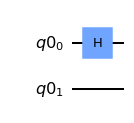

In [2]:
circ.h(qr[0])
circ.draw(output="mpl")

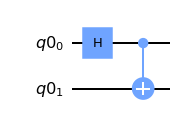

In [3]:
# Now we apply the CNOT gate
circ.cx(qr[0], qr[1])
circ.draw(output="mpl")

Does this ring a **bell**?

The output of this circuit is indeed the Bell state $\vert\beta_{00}\rangle$! Let's see better:

### $\frac{\vert0\rangle + \vert1\rangle}{\sqrt{2}} \otimes \vert0\rangle = \frac{\vert00\rangle + \vert10\rangle}{\sqrt{2}} \xrightarrow{\text{CNOT}} \frac{\vert00\rangle + \vert11\rangle}{\sqrt{2}} = \vert\beta_{00}\rangle$

## Second Example: Toffoli Gate

What if we control the CNOT gate? We get another well-known gate called Toffoli or CCNOT or CCX gate.

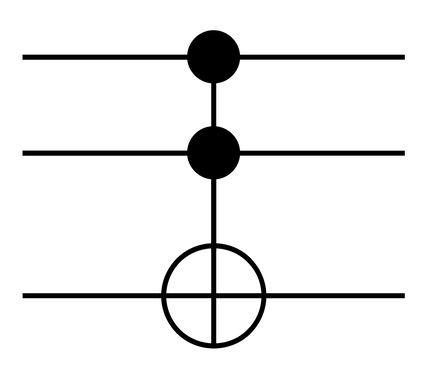

It is a 3-qubits gate with 2 control qubits and a target qubit. The NOT operator is applied on the target qubit if and only if the control qubits state is $\vert11\rangle$.

In other words $CCNOT\vert110\rangle = \vert111\rangle$, $CCNOT\vert111\rangle = \vert110\rangle$, while it acts as an identity on all the other input basis states.

$CCNOT=\begin{pmatrix}1&0&0&0&0&0&0&0 \\ 0&1&0&0&0&0&0&0 \\ 0&0&1&0&0&0&0&0 \\ 0&0&0&1&0&0&0&0 \\ 0&0&0&0&1&0&0&0 \\ 0&0&0&0&0&1&0&0 \\ 0&0&0&0&0&0&0&1 \\ 0&0&0&0&0&0&1&0 \end{pmatrix}$

Let's see the gate in action!

In [18]:
cr = ClassicalRegister(3)
qr = QuantumRegister(3)

toff_circ = QuantumCircuit(qr, cr)

We initialize the two control qubits to an arbitrary state vector, let's see how:

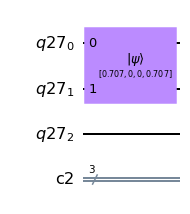

In [19]:
import math

control_state_1 = [0., 0., 0., 1.]  # |11>
control_state_2 = [1/2, 1/2, 1/2, 1/2] # 1/2|00> + 1/2|01> + 1/2|10> + 1/2|11> 
control_state_3 = [1/math.sqrt(2), 0., 0., 1/math.sqrt(2)] # 1/sqrt(2)|00> + 1/sqrt(2)|11>

from qiskit.extensions import Initialize

init_instr = Initialize(control_state_3)

toff_circ.append(init_instr, qr[0:2])

toff_circ.draw(output="mpl")

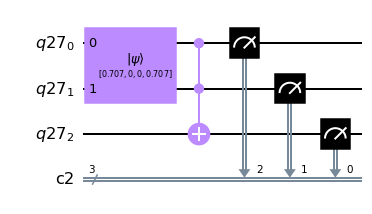

In [20]:
# Now we apply the Toffoli gate
toff_circ.ccx(qr[0], qr[1], qr[2], ctrl_state="11")

toff_circ.measure(qr[:], cr[::-1])

toff_circ.draw(output="mpl")

Let's run our circuit on a simulator!

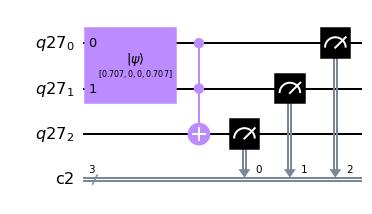

In [21]:
from qiskit import Aer

# We get a qasm simulator as backend from Aer
backend = Aer.get_backend('qasm_simulator')

from qiskit.compiler import transpile
tr_circ = transpile(toff_circ, backend, optimization_level=1)

tr_circ.draw(output="mpl")

In [22]:
# We define our job
job = backend.run(tr_circ, shots=2048)

# We execute and collect the results:
result = job.result()

# We collect the measurements in a dictionary
counts = result.get_counts()

print(counts)

{'000': 1029, '111': 1019}


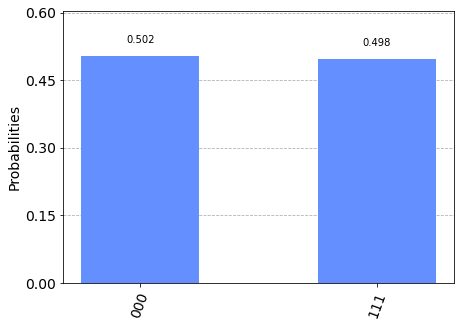

In [23]:
from qiskit.visualization import plot_histogram

plot_histogram(counts)

## Arbitrary controlled gate

Any quantum gate can be controlled by one or more control qubits. This might turn useful in many practical applications.

For example, let's build a controlled version of a BELL gate:

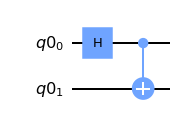

In [24]:
circ.draw(output="mpl")

In [26]:
# Cast our Bell circuit into a Qiskit Quantum Gate instance
bell_gate = circ.to_gate(label="BELL")

# We apply the control() method from the Gate class to generate a new controlled gate
c_bell = bell_gate.control(num_ctrl_qubits=1, label="CBell", ctrl_state="1")

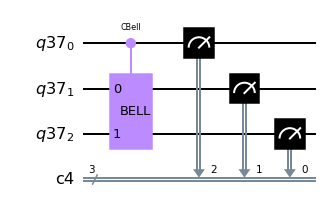

In [27]:
# Let's write down a circuit with our new controlled Bell gate
qr = QuantumRegister(3)
cr = ClassicalRegister(3)

cbell_circ = QuantumCircuit(qr, cr)
cbell_circ.append(c_bell, qr[:])

cbell_circ.measure(qr[:], cr[::-1])

cbell_circ.draw(output="mpl")

In [ ]:
qr = QuantumRegister(4)

circ = QuantumCircuit(qr)

ccbell = bell_gate.control(num_ctrl_qubits=2, label="CCBell", ctrl_stat)

## Exercise: Write down a circuit with a CCBell gate, which is a Bell gate controlled by 2 qubits in state $\vert11\rangle$

In [ ]:
ccbell = bell_gate.control(num_ctrl_qubits=2, label="CCBell", ctrl_state="11")

# Let's write down a circuit with our new controlled Bell gate
qr = QuantumRegister(4)
cr = ClassicalRegister(4)

cbell_circ = QuantumCircuit(qr, cr)
cbell_circ.append(cc_bell, qr[:])

cbell_circ.measure(qr[:], cr[::-1])

cbell_circ.draw(output="mpl")